<a href="https://colab.research.google.com/github/yashwini321/yashwini/blob/main/stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ML RMSE: 23.8354036961505
LSTM RMSE: 7.729889801904497


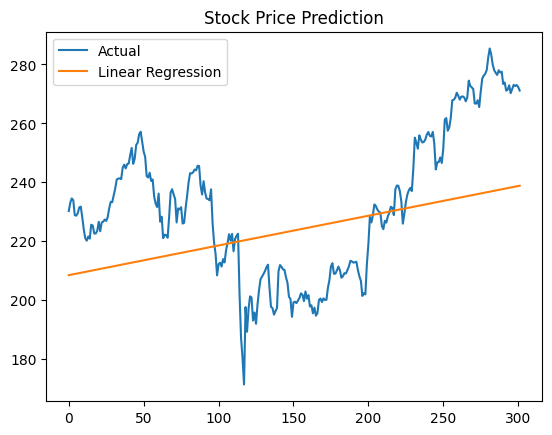

In [4]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

data = yf.download("AAPL", start="2020-01-01", end="2026-01-01",
                   auto_adjust=True)["Close"].dropna()
X = np.arange(len(data)).reshape(-1,1)
y = data.values
split = int(len(X)*0.8)

model = LinearRegression()
model.fit(X[:split], y[:split])
pred = model.predict(X[split:])
print("ML RMSE:",
      np.sqrt(mean_squared_error(y[split:], pred)))

scaler = MinMaxScaler()
scaled = scaler.fit_transform(y.reshape(-1,1))
X_lstm, y_lstm = [], []
for i in range(30, len(scaled)):
    X_lstm.append(scaled[i-30:i])
    y_lstm.append(scaled[i])
X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)
split_lstm = int(len(X_lstm)*0.8)

lstm = Sequential([
    LSTM(50, input_shape=(30,1)),
    Dense(1)
])
lstm.compile(optimizer="adam", loss="mse")
lstm.fit(X_lstm[:split_lstm], y_lstm[:split_lstm],
         epochs=10, batch_size=32, verbose=0)

prediction = lstm.predict(X_lstm[split_lstm:], verbose=0)
prediction = scaler.inverse_transform(prediction)

# Using negative slicing to ensure exact matches
print("LSTM RMSE:", np.sqrt(mean_squared_error(y[-len(prediction):], prediction)))

plt.plot(y[split:], label="Actual")
plt.plot(pred, label="Linear Regression")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()